<a href="https://colab.research.google.com/github/Ayushpal2006/ML-model-EDA-AND-TRAINING-DATA-SET/blob/main/%E0%A4%B8%E0%A4%82%E0%A4%9C%E0%A5%80%E0%A4%B5%E0%A4%A8%E0%A5%80.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [10]:
import kagglehub

# Download latest version // KISI KAAM KA NHI HAI
path = kagglehub.dataset_download("prasoonkottarathil/polycystic-ovary-syndrome-pcos")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'polycystic-ovary-syndrome-pcos' dataset.
Path to dataset files: /kaggle/input/polycystic-ovary-syndrome-pcos


In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


In [13]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve
)

In [14]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [15]:
import joblib

In [16]:
df = pd.read_excel("/content/drive/MyDrive/Colab Notebooks/PCOS_data_without_infertility.xlsx",sheet_name='Full_new')

df.head()

,Sl. No,Patient File No.,PCOS (Y/N),Age (yrs),Weight (Kg),Height(Cm),BMI,Blood Group,Pulse rate(bpm),RR (breaths/min),...,Fast food (Y/N),Reg.Exercise(Y/N),BP _Systolic (mmHg),BP _Diastolic (mmHg),Follicle No. (L),Follicle No. (R),Avg. F size (L) (mm),Avg. F size (R) (mm),Endometrium (mm),Unnamed: 44
0,1,1,0,28,44.6,152.0,19.300000,15,78,22,...,1.0,0,110,80,3,3,18.0,18.0,8.5,NaN
1,2,2,0,36,65.0,161.5,24.921163,15,74,20,...,0.0,0,120,70,3,5,15.0,14.0,3.7,NaN
2,3,3,1,33,68.8,165.0,25.270891,11,72,18,...,1.0,0,120,80,13,15,18.0,20.0,10.0,NaN
3,4,4,0,37,65.0,148.0,29.674945,13,72,20,...,0.0,0,120,70,2,2,15.0,14.0,7.5,NaN
4,5,5,0,25,52.0,161.0,20.060954,11,72,18,...,0.0,0,120,80,3,4,16.0,14.0,7.0,NaN


In [17]:
print("Dataset Shape:")
print(df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nData Info:")
df.info()

Dataset Shape:
(541, 45)

Columns:
['Sl. No', 'Patient File No.', 'PCOS (Y/N)', ' Age (yrs)', 'Weight (Kg)', 'Height(Cm) ', 'BMI', 'Blood Group', 'Pulse rate(bpm) ', 'RR (breaths/min)', 'Hb(g/dl)', 'Cycle(R/I)', 'Cycle length(days)', 'Marraige Status (Yrs)', 'Pregnant(Y/N)', 'No. of aborptions', '  I   beta-HCG(mIU/mL)', 'II    beta-HCG(mIU/mL)', 'FSH(mIU/mL)', 'LH(mIU/mL)', 'FSH/LH', 'Hip(inch)', 'Waist(inch)', 'Waist:Hip Ratio', 'TSH (mIU/L)', 'AMH(ng/mL)', 'PRL(ng/mL)', 'Vit D3 (ng/mL)', 'PRG(ng/mL)', 'RBS(mg/dl)', 'Weight gain(Y/N)', 'hair growth(Y/N)', 'Skin darkening (Y/N)', 'Hair loss(Y/N)', 'Pimples(Y/N)', 'Fast food (Y/N)', 'Reg.Exercise(Y/N)', 'BP _Systolic (mmHg)', 'BP _Diastolic (mmHg)', 'Follicle No. (L)', 'Follicle No. (R)', 'Avg. F size (L) (mm)', 'Avg. F size (R) (mm)', 'Endometrium (mm)', 'Unnamed: 44']

Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541 entries, 0 to 540
Data columns (total 45 columns):
 #   Column                  Non-Null Count  Dtype 

In [18]:
df.isnull().sum()

,0
Sl. No,0
Patient File No.,0
PCOS (Y/N),0
Age (yrs),0
Weight (Kg),0
Height(Cm),0
BMI,0
Blood Group,0
Pulse rate(bpm),0
RR (breaths/min),0


In [19]:
df_clean = df.copy()

In [20]:
df_clean = df_clean.drop(
    columns=["Sl. No", "Patient File No.", "Unnamed: 44"],
    errors="ignore"
)

In [21]:
df_clean.columns = df_clean.columns.str.strip()

In [22]:
df_clean

,PCOS (Y/N),Age (yrs),Weight (Kg),Height(Cm),BMI,Blood Group,Pulse rate(bpm),RR (breaths/min),Hb(g/dl),Cycle(R/I),...,Pimples(Y/N),Fast food (Y/N),Reg.Exercise(Y/N),BP _Systolic (mmHg),BP _Diastolic (mmHg),Follicle No. (L),Follicle No. (R),Avg. F size (L) (mm),Avg. F size (R) (mm),Endometrium (mm)
0,0,28,44.6,152.000,19.300000,15,78,22,10.48,2,...,0,1.0,0,110,80,3,3,18.0,18.0,8.5
1,0,36,65.0,161.500,24.921163,15,74,20,11.70,2,...,0,0.0,0,120,70,3,5,15.0,14.0,3.7
2,1,33,68.8,165.000,25.270891,11,72,18,11.80,2,...,1,1.0,0,120,80,13,15,18.0,20.0,10.0
3,0,37,65.0,148.000,29.674945,13,72,20,12.00,2,...,0,0.0,0,120,70,2,2,15.0,14.0,7.5
4,0,25,52.0,161.000,20.060954,11,72,18,10.00,2,...,0,0.0,0,120,80,3,4,16.0,14.0,7.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
536,0,35,50.0,164.592,18.500000,17,72,16,11.00,2,...,0,0.0,0,110,70,1,0,17.5,10.0,6.7
537,0,30,63.2,158.000,25.300000,15,72,18,10.80,2,...,0,0.0,0,110,70,9,7,19.0,18.0,8.2
538,0,36,54.0,152.000,23.400000,13,74,20,10.80,2,...,0,0.0,0,110,80,1,0,18.0,9.0,7.3
539,0,27,50.0,150.000,22.200000,15,74,20,12.00,4,...,1,0.0,0,110,70,7,6,18.0,16.0,11.5


In [23]:
print("New Shape:", df_clean.shape)
print("\nColumns:")
print(df_clean.columns.tolist())

New Shape: (541, 42)

Columns:
['PCOS (Y/N)', 'Age (yrs)', 'Weight (Kg)', 'Height(Cm)', 'BMI', 'Blood Group', 'Pulse rate(bpm)', 'RR (breaths/min)', 'Hb(g/dl)', 'Cycle(R/I)', 'Cycle length(days)', 'Marraige Status (Yrs)', 'Pregnant(Y/N)', 'No. of aborptions', 'I   beta-HCG(mIU/mL)', 'II    beta-HCG(mIU/mL)', 'FSH(mIU/mL)', 'LH(mIU/mL)', 'FSH/LH', 'Hip(inch)', 'Waist(inch)', 'Waist:Hip Ratio', 'TSH (mIU/L)', 'AMH(ng/mL)', 'PRL(ng/mL)', 'Vit D3 (ng/mL)', 'PRG(ng/mL)', 'RBS(mg/dl)', 'Weight gain(Y/N)', 'hair growth(Y/N)', 'Skin darkening (Y/N)', 'Hair loss(Y/N)', 'Pimples(Y/N)', 'Fast food (Y/N)', 'Reg.Exercise(Y/N)', 'BP _Systolic (mmHg)', 'BP _Diastolic (mmHg)', 'Follicle No. (L)', 'Follicle No. (R)', 'Avg. F size (L) (mm)', 'Avg. F size (R) (mm)', 'Endometrium (mm)']


In [24]:
df_clean["PCOS (Y/N)"].value_counts()

,count
PCOS (Y/N),
0,364
1,177


In [25]:
features = [
    "Age (yrs)",
    "Weight (Kg)",
    "Height(Cm)",
    "BMI",
    "Cycle(R/I)",
    "Cycle length(days)",
    "Weight gain(Y/N)",
    "hair growth(Y/N)",
    "Skin darkening (Y/N)",
    "Hair loss(Y/N)",
    "Pimples(Y/N)",
    "Fast food (Y/N)",
    "Reg.Exercise(Y/N)"
]

target = "PCOS (Y/N)"

In [26]:
ml_df = df_clean[features + [target]].copy()

print("ML Dataset Shape:", ml_df.shape)

ML Dataset Shape: (541, 14)


In [27]:
print("\nMissing Values:")
print(ml_df.isnull().sum())


Missing Values:
Age (yrs)               0
Weight (Kg)             0
Height(Cm)              0
BMI                     0
Cycle(R/I)              0
Cycle length(days)      0
Weight gain(Y/N)        0
hair growth(Y/N)        0
Skin darkening (Y/N)    0
Hair loss(Y/N)          0
Pimples(Y/N)            0
Fast food (Y/N)         1
Reg.Exercise(Y/N)       0
PCOS (Y/N)              0
dtype: int64


In [28]:
print("\nFirst 5 rows:")
display(ml_df.head())


First 5 rows:


,Age (yrs),Weight (Kg),Height(Cm),BMI,Cycle(R/I),Cycle length(days),Weight gain(Y/N),hair growth(Y/N),Skin darkening (Y/N),Hair loss(Y/N),Pimples(Y/N),Fast food (Y/N),Reg.Exercise(Y/N),PCOS (Y/N)
0,28,44.6,152.0,19.300000,2,5,0,0,0,0,0,1.0,0,0
1,36,65.0,161.5,24.921163,2,5,0,0,0,0,0,0.0,0,0
2,33,68.8,165.0,25.270891,2,5,0,0,0,1,1,1.0,0,1
3,37,65.0,148.0,29.674945,2,5,0,0,0,0,0,0.0,0,0
4,25,52.0,161.0,20.060954,2,5,0,0,0,1,0,0.0,0,0


In [29]:
ml_df["Fast food (Y/N)"] = ml_df["Fast food (Y/N)"].fillna(
    ml_df["Fast food (Y/N)"].mode()[0]
)

In [30]:
print(ml_df.isnull().sum())

Age (yrs)               0
Weight (Kg)             0
Height(Cm)              0
BMI                     0
Cycle(R/I)              0
Cycle length(days)      0
Weight gain(Y/N)        0
hair growth(Y/N)        0
Skin darkening (Y/N)    0
Hair loss(Y/N)          0
Pimples(Y/N)            0
Fast food (Y/N)         0
Reg.Exercise(Y/N)       0
PCOS (Y/N)              0
dtype: int64


In [31]:
X = ml_df.drop("PCOS (Y/N)", axis=1)
y = ml_df["PCOS (Y/N)"]

In [32]:
print("X Shape:", X.shape)
print("y Shape:", y.shape)

X Shape: (541, 13)
y Shape: (541,)


In [33]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [34]:
print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts())

print("\nTesting target distribution:")
print(y_test.value_counts())

Training data: (432, 13)
Testing data: (109, 13)

Training target distribution:
PCOS (Y/N)
0    291
1    141
Name: count, dtype: int64

Testing target distribution:
PCOS (Y/N)
0    73
1    36
Name: count, dtype: int64


In [35]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,classification_report,confusion_matrix

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [36]:
log_model = LogisticRegression(random_state=42,max_iter=1000)
log_model.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [37]:
log_model.score(X_train_scaled, y_train)

0.8564814814814815

In [38]:
y_pred_log = log_model.predict(X_test_scaled)


In [39]:
print("Logistic Regression Results\n")

print("Accuracy:", round(accuracy_score(y_test, y_pred_log), 4))
print("Precision:", round(precision_score(y_test, y_pred_log), 4))
print("Recall:", round(recall_score(y_test, y_pred_log), 4))
print("F1 Score:", round(f1_score(y_test, y_pred_log), 4))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_log))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_log))

Logistic Regression Results

Accuracy: 0.8716
Precision: 0.8438
Recall: 0.75
F1 Score: 0.7941

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.93      0.91        73
           1       0.84      0.75      0.79        36

    accuracy                           0.87       109
   macro avg       0.86      0.84      0.85       109
weighted avg       0.87      0.87      0.87       109


Confusion Matrix:
[[68  5]
 [ 9 27]]


In [40]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(
    random_state=42
)


dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)


print("Decision Tree Results\n")

print("Accuracy:", round(accuracy_score(y_test, y_pred_dt), 4))
print("Precision:", round(precision_score(y_test, y_pred_dt), 4))
print("Recall:", round(recall_score(y_test, y_pred_dt), 4))
print("F1 Score:", round(f1_score(y_test, y_pred_dt), 4))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_dt))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_dt))

Decision Tree Results

Accuracy: 0.7431
Precision: 0.6176
Recall: 0.5833
F1 Score: 0.6

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.82      0.81        73
           1       0.62      0.58      0.60        36

    accuracy                           0.74       109
   macro avg       0.71      0.70      0.71       109
weighted avg       0.74      0.74      0.74       109


Confusion Matrix:
[[60 13]
 [15 21]]


In [41]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print("Random Forest Results\n")

print("Accuracy:", round(accuracy_score(y_test, y_pred_rf), 4))
print("Precision:", round(precision_score(y_test, y_pred_rf), 4))
print("Recall:", round(recall_score(y_test, y_pred_rf), 4))
print("F1 Score:", round(f1_score(y_test, y_pred_rf), 4))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

Random Forest Results

Accuracy: 0.8532
Precision: 0.8333
Recall: 0.6944
F1 Score: 0.7576

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.93      0.89        73
           1       0.83      0.69      0.76        36

    accuracy                           0.85       109
   macro avg       0.85      0.81      0.83       109
weighted avg       0.85      0.85      0.85       109


Confusion Matrix:
[[68  5]
 [11 25]]


In [42]:
from sklearn.metrics import roc_auc_score, roc_curve

y_prob_log = log_model.predict_proba(X_test_scaled)[:, 1]

auc_score = roc_auc_score(y_test, y_prob_log)

print("Logistic Regression ROC-AUC:", round(auc_score, 4))

Logistic Regression ROC-AUC: 0.8855


In [43]:
thresholds = [0.3, 0.4, 0.5, 0.6, 0.7]

for threshold in thresholds:
    y_pred_threshold = (y_prob_log >= threshold).astype(int)

    print(f"\nThreshold: {threshold}")
    print("Precision:", round(precision_score(y_test, y_pred_threshold), 4))
    print("Recall:", round(recall_score(y_test, y_pred_threshold), 4))
    print("F1 Score:", round(f1_score(y_test, y_pred_threshold), 4))
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred_threshold))


Threshold: 0.3
Precision: 0.7436
Recall: 0.8056
F1 Score: 0.7733
Confusion Matrix:
[[63 10]
 [ 7 29]]

Threshold: 0.4
Precision: 0.8056
Recall: 0.8056
F1 Score: 0.8056
Confusion Matrix:
[[66  7]
 [ 7 29]]

Threshold: 0.5
Precision: 0.8438
Recall: 0.75
F1 Score: 0.7941
Confusion Matrix:
[[68  5]
 [ 9 27]]

Threshold: 0.6
Precision: 0.8929
Recall: 0.6944
F1 Score: 0.7812
Confusion Matrix:
[[70  3]
 [11 25]]

Threshold: 0.7
Precision: 0.9048
Recall: 0.5278
F1 Score: 0.6667
Confusion Matrix:
[[71  2]
 [17 19]]


In [44]:
print(ml_df["Cycle(R/I)"].value_counts())

Cycle(R/I)
2    390
4    150
5      1
Name: count, dtype: int64


In [45]:
ml_df[ml_df["Cycle(R/I)"] == 5]

,Age (yrs),Weight (Kg),Height(Cm),BMI,Cycle(R/I),Cycle length(days),Weight gain(Y/N),hair growth(Y/N),Skin darkening (Y/N),Hair loss(Y/N),Pimples(Y/N),Fast food (Y/N),Reg.Exercise(Y/N),PCOS (Y/N)
512,23,72.0,165.0,26.4,5,7,0,1,1,0,0,1.0,0,1


In [46]:
pd.crosstab(
    ml_df["Cycle(R/I)"],
    ml_df["PCOS (Y/N)"],
    margins=True
)

PCOS (Y/N),0,1,All
Cycle(R/I),,,
2,308,82,390
4,56,94,150
5,0,1,1
All,364,177,541


In [47]:
ml_df["Cycle(R/I)"] = ml_df["Cycle(R/I)"].replace(5, 4)

print(ml_df["Cycle(R/I)"].value_counts())

Cycle(R/I)
2    390
4    151
Name: count, dtype: int64


In [48]:

X = ml_df.drop("PCOS (Y/N)", axis=1)
y = ml_df["PCOS (Y/N)"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

print("\nCycle values:")
print(X["Cycle(R/I)"].value_counts())

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

log_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

log_model.fit(X_train_scaled, y_train)

y_pred_log = log_model.predict(X_test_scaled)
y_prob_log = log_model.predict_proba(X_test_scaled)[:, 1]

print("Logistic Regression Results\n")

print("Accuracy:", round(accuracy_score(y_test, y_pred_log), 4))
print("Precision:", round(precision_score(y_test, y_pred_log), 4))
print("Recall:", round(recall_score(y_test, y_pred_log), 4))
print("F1 Score:", round(f1_score(y_test, y_pred_log), 4))
print("ROC-AUC:", round(roc_auc_score(y_test, y_prob_log), 4))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_log))

thresholds = [0.3, 0.4, 0.5, 0.6, 0.7]

for threshold in thresholds:
    y_pred_threshold = (y_prob_log >= threshold).astype(int)

    cm = confusion_matrix(y_test, y_pred_threshold)

    print(f"\nThreshold: {threshold}")
    print("Precision:", round(precision_score(y_test, y_pred_threshold), 4))
    print("Recall:", round(recall_score(y_test, y_pred_threshold), 4))
    print("F1 Score:", round(f1_score(y_test, y_pred_threshold), 4))
    print("False Negatives:", cm[1][0])
    print("False Positives:", cm[0][1])

Training data: (432, 13)
Testing data: (109, 13)

Cycle values:
Cycle(R/I)
2    390
4    151
Name: count, dtype: int64
Logistic Regression Results

Accuracy: 0.8716
Precision: 0.8438
Recall: 0.75
F1 Score: 0.7941
ROC-AUC: 0.8855

Confusion Matrix:
[[68  5]
 [ 9 27]]

Threshold: 0.3
Precision: 0.7436
Recall: 0.8056
F1 Score: 0.7733
False Negatives: 7
False Positives: 10

Threshold: 0.4
Precision: 0.8056
Recall: 0.8056
F1 Score: 0.8056
False Negatives: 7
False Positives: 7

Threshold: 0.5
Precision: 0.8438
Recall: 0.75
F1 Score: 0.7941
False Negatives: 9
False Positives: 5

Threshold: 0.6
Precision: 0.8929
Recall: 0.6944
F1 Score: 0.7812
False Negatives: 11
False Positives: 3

Threshold: 0.7
Precision: 0.9048
Recall: 0.5278
F1 Score: 0.6667
False Negatives: 17
False Positives: 2


In [49]:
import joblib

model_package = {
    "model": log_model,
    "scaler": scaler,
    "features": list(X.columns),
    "threshold": 0.4,
    "model_name": "Logistic Regression",
    "model_version": "1.0"
}

joblib.dump(model_package, "sanjivani_model.pkl")

print("Model saved successfully!")
print("\nFeatures used:")
print(model_package["features"])

Model saved successfully!

Features used:
['Age (yrs)', 'Weight (Kg)', 'Height(Cm)', 'BMI', 'Cycle(R/I)', 'Cycle length(days)', 'Weight gain(Y/N)', 'hair growth(Y/N)', 'Skin darkening (Y/N)', 'Hair loss(Y/N)', 'Pimples(Y/N)', 'Fast food (Y/N)', 'Reg.Exercise(Y/N)']


In [50]:
from google.colab import files

files.download("sanjivani_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

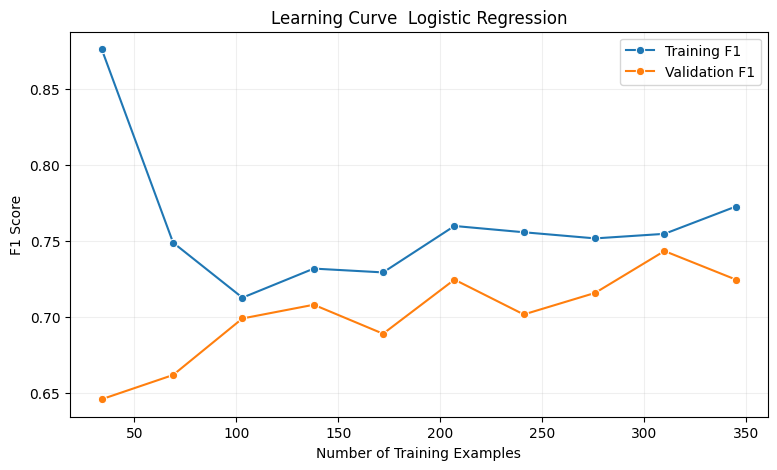

In [52]:
from sklearn.model_selection import learning_curve
import numpy as np

train_sizes, train_scores, validation_scores = learning_curve(
    log_model,
    X_train_scaled,
    y_train,
    cv=5,
    scoring="f1",
    train_sizes=np.linspace(0.1, 1.0, 10),
    random_state=42
)

train_mean = train_scores.mean(axis=1)
validation_mean = validation_scores.mean(axis=1)

plt.figure(figsize=(9, 5))

sns.lineplot(
    x=train_sizes,
    y=train_mean,
    marker="o",
    label="Training F1"
)

sns.lineplot(
    x=train_sizes,
    y=validation_mean,
    marker="o",
    label="Validation F1"
)

plt.xlabel("Number of Training Examples")
plt.ylabel("F1 Score")
plt.title("Learning Curve  Logistic Regression")
plt.grid(alpha=0.2)
plt.legend()

plt.show()

In [53]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline

# Pipeline prevents scaling leakage inside cross-validation
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000, random_state=42))
])

# 5-fold stratified cross-validation
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

f1_scores = cross_val_score(
    pipeline,
    X,
    y,
    cv=cv,
    scoring="f1"
)

roc_auc_scores = cross_val_score(
    pipeline,
    X,
    y,
    cv=cv,
    scoring="roc_auc"
)

print("F1 scores for each fold:", f1_scores)
print("\nMean F1:", round(f1_scores.mean(), 4))
print("F1 Standard Deviation:", round(f1_scores.std(), 4))

print("\nROC-AUC scores for each fold:", roc_auc_scores)
print("\nMean ROC-AUC:", round(roc_auc_scores.mean(), 4))
print("ROC-AUC Standard Deviation:", round(roc_auc_scores.std(), 4))

F1 scores for each fold: [0.76470588 0.76923077 0.85294118 0.71232877 0.73529412]

Mean F1: 0.7669
F1 Standard Deviation: 0.0477

ROC-AUC scores for each fold: [0.91362253 0.8888454  0.9037182  0.84383562 0.86959877]

Mean ROC-AUC: 0.8839
ROC-AUC Standard Deviation: 0.0249


In [57]:
import joblib

model_package = {
    "model": log_model,
    "scaler": scaler,
    "features": list(X.columns),
    "threshold": 0.4
}

joblib.dump(model_package, "sanjivani_model.pkl")

print("Model saved successfully!")

Model saved successfully!


In [58]:
from google.colab import files

files.download("sanjivani_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [55]:
import joblib
import pandas as pd

# Load saved model package
loaded_package = joblib.load("sanjivani_model.pkl")

print("Model loaded successfully!")

print("\nFeatures:")
print(loaded_package["features"])

print("\nThreshold:")
print(loaded_package["threshold"])

Model loaded successfully!

Features:
['Age (yrs)', 'Weight (Kg)', 'Height(Cm)', 'BMI', 'Cycle(R/I)', 'Cycle length(days)', 'Weight gain(Y/N)', 'hair growth(Y/N)', 'Skin darkening (Y/N)', 'Hair loss(Y/N)', 'Pimples(Y/N)', 'Fast food (Y/N)', 'Reg.Exercise(Y/N)']

Threshold:
0.4


In [56]:
# Example patient data

sample_patient = {
    "Age (yrs)": 28,
    "Weight (Kg)": 70,
    "Height(Cm)": 160,
    "BMI": 27.34,
    "Cycle(R/I)": 4,
    "Cycle length(days)": 40,
    "Weight gain(Y/N)": 1,
    "hair growth(Y/N)": 1,
    "Skin darkening (Y/N)": 1,
    "Hair loss(Y/N)": 1,
    "Pimples(Y/N)": 1,
    "Fast food (Y/N)": 1,
    "Reg.Exercise(Y/N)": 0
}

# Convert to DataFrame
sample_df = pd.DataFrame([sample_patient])

# Ensure exact feature order
sample_df = sample_df[loaded_package["features"]]

# Extract model and scaler
loaded_model = loaded_package["model"]
loaded_scaler = loaded_package["scaler"]
threshold = loaded_package["threshold"]

# Scale input
sample_scaled = loaded_scaler.transform(sample_df)

# Get probability
probability = loaded_model.predict_proba(sample_scaled)[0][1]

# Apply our threshold
prediction = int(probability >= threshold)

print("PCOS-related risk probability:", round(probability, 4))
print("Threshold:", threshold)
print("Prediction:", prediction)

if prediction == 1:
    print("Result: Elevated PCOS-related risk")
else:
    print("Result: Lower PCOS-related risk")

PCOS-related risk probability: 0.0069
Threshold: 0.4
Prediction: 0
Result: Lower PCOS-related risk


In [59]:
# Pick one actual PCOS-positive patient from test data
positive_index = y_test[y_test == 1].index[0]

real_positive = X_test.loc[[positive_index]]

# Actual label
print("Actual PCOS label:", y_test.loc[positive_index])

# Scale and predict
real_positive_scaled = loaded_scaler.transform(real_positive)

probability = loaded_model.predict_proba(
    real_positive_scaled
)[0][1]

prediction = int(probability >= threshold)

print("Predicted probability:", round(probability, 4))
print("Prediction using threshold 0.4:", prediction)

print("\nPatient features:")
display(real_positive)

Actual PCOS label: 1
Predicted probability: 0.1025
Prediction using threshold 0.4: 0

Patient features:


,Age (yrs),Weight (Kg),Height(Cm),BMI,Cycle(R/I),Cycle length(days),Weight gain(Y/N),hair growth(Y/N),Skin darkening (Y/N),Hair loss(Y/N),Pimples(Y/N),Fast food (Y/N),Reg.Exercise(Y/N)
444,27,52.0,150.0,23.1,2,5,0,0,0,0,0,1.0,1


In [60]:
# Get probabilities for the entire test set
test_probabilities = loaded_model.predict_proba(
    loaded_scaler.transform(X_test)
)[:, 1]

# Create a results dataframe
results = X_test.copy()

results["Actual"] = y_test
results["Probability"] = test_probabilities
results["Prediction"] = (test_probabilities >= 0.4).astype(int)

# Show correctly predicted PCOS-positive cases
correct_positive = results[
    (results["Actual"] == 1) &
    (results["Prediction"] == 1)
].sort_values("Probability", ascending=False)

display(correct_positive.head())

,Age (yrs),Weight (Kg),Height(Cm),BMI,Cycle(R/I),Cycle length(days),Weight gain(Y/N),hair growth(Y/N),Skin darkening (Y/N),Hair loss(Y/N),Pimples(Y/N),Fast food (Y/N),Reg.Exercise(Y/N),Actual,Probability,Prediction
26,30,76.0,160.0,29.687500,4,3,1,1,1,1,1,1.0,1,1,0.978131,1
205,28,62.0,160.0,24.218750,4,5,1,1,1,0,1,1.0,1,1,0.973110,1
356,32,80.4,165.0,29.500000,4,3,1,1,1,0,1,1.0,0,1,0.965797,1
199,25,58.0,160.0,22.656250,4,3,1,1,1,1,0,1.0,0,1,0.962545,1
44,29,59.0,158.0,23.634033,4,7,1,1,1,1,1,1.0,1,1,0.954339,1
